In [22]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [23]:
# extra code – loads, scales, and splits the fashion MNIST dataset
fashion_mnist = tf.keras.datasets.mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train_full = X_train_full.astype(np.float32) / 255
X_test = X_test.astype(np.float32) / 255
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

In [24]:
def plot_multiple_images(images, n_cols=None):
    n_cols = n_cols or len(images)
    n_rows = (len(images) - 1) // n_cols + 1
    if images.shape[-1] == 1:
        images = images.squeeze(axis=-1)
    plt.figure(figsize=(n_cols, n_rows))
    for index, image in enumerate(images):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(image, cmap="binary")
        plt.axis("off")

In [25]:
batch_size = 32
dataset = tf.data.Dataset.from_tensor_slices(X_train).shuffle(1000)
dataset = dataset.batch(batch_size, drop_remainder=True).prefetch(1)

In [26]:
def train_gan(gan, dataset, batch_size, codings_size, n_epochs):
    generator, discriminator = gan.layers
    for epoch in range(n_epochs):
        print(f"Epoch {epoch + 1}/{n_epochs}")  # extra code
        for X_batch in dataset:
            # phase 1 - training the discriminator
            noise = tf.random.normal(shape=[batch_size, codings_size])
            generated_images = generator(noise)
            X_fake_and_real = tf.concat([generated_images, X_batch], axis=0)
            y1 = tf.constant([[0.]] * batch_size + [[1.]] * batch_size)
            discriminator.trainable = True
            discriminator.train_on_batch(X_fake_and_real, y1)
            discriminator.trainable = False
            # phase 2 - training the generator
            noise = tf.random.normal(shape=[batch_size, codings_size])
            y2 = tf.constant([[1.]] * batch_size)
            gan.train_on_batch(noise, y2)
        # extra code — plot images during training
        plot_multiple_images(generated_images.numpy(), 8)
        plt.show()

In [27]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU

def build_dcgan(codings_size):
    # Generador
    generator = tf.keras.Sequential([
        tf.keras.layers.Dense(7 * 7 * 128, input_shape=[codings_size]), # Importante: input_shape explícito
        tf.keras.layers.Reshape([7, 7, 128]),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2DTranspose(64, kernel_size=5, strides=2, padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2DTranspose(1, kernel_size=5, strides=2, padding="same", activation="tanh"),
    ])

    # Discriminador
    discriminator = tf.keras.Sequential([
        tf.keras.layers.Conv2D(64, kernel_size=5, strides=2, padding="same",
                            activation=tf.keras.layers.LeakyReLU(0.2), input_shape=[28, 28, 1]),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Conv2D(128, kernel_size=5, strides=2, padding="same",
                            activation=tf.keras.layers.LeakyReLU(0.2)),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    gan = tf.keras.Sequential([generator, discriminator])

    # Compilamos
    discriminator.compile(loss="binary_crossentropy", optimizer="rmsprop")
    discriminator.trainable = False
    gan.compile(loss="binary_crossentropy", optimizer="rmsprop")

    return gan, generator, discriminator

In [28]:
# PREPARACIÓN DE DATOS
X_train_dcgan = X_train.reshape(-1, 28, 28, 1) * 2. - 1.
batch_size = 32
dataset = tf.data.Dataset.from_tensor_slices(X_train_dcgan)
dataset = dataset.shuffle(1000)
dataset = dataset.batch(batch_size, drop_remainder=True).prefetch(1)

In [29]:
# BUCLE DE EXPERIMENTACIÓN
sizes_to_test = [10, 50, 100]
trained_generators = {}

for size in sizes_to_test:
    print(f"\nEntrenando DCGAN con vector de entrada: {size}")
    gan, generator, _ = build_dcgan(size)
    train_gan(gan, dataset, batch_size, size, n_epochs=10) # Ajusta n_epochs (DCGAN tarda más)
    trained_generators[size] = generator

Output hidden; open in https://colab.research.google.com to view.


--- COMPARATIVA FINAL ---
Resultados con tamaño 10:


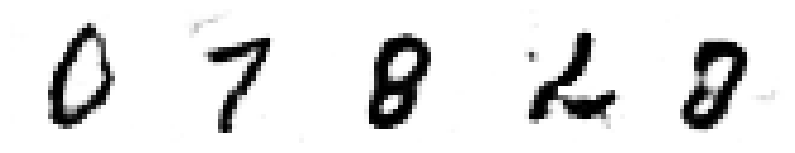

Resultados con tamaño 50:


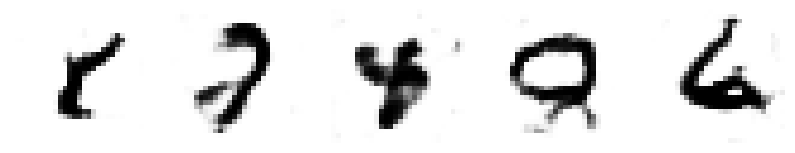

Resultados con tamaño 100:


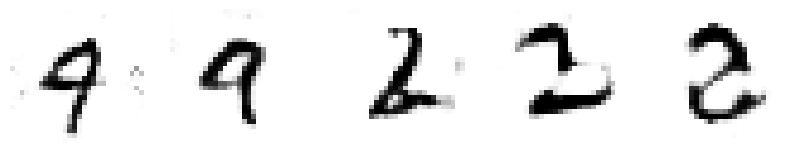

In [30]:
# VISUALIZACIÓN FINAL
def plot_generated_images(generator, codings_size, num_images=5):
    noise = tf.random.normal(shape=[num_images, codings_size])
    generated_images = generator(noise)
    plt.figure(figsize=(10, 2))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(generated_images[i, :, :, 0], cmap="binary") # Nota el índice extra para canal
        plt.axis("off")
    plt.show()

print("\n--- COMPARATIVA FINAL ---")
for size in sizes_to_test:
    print(f"Resultados con tamaño {size}:")
    plot_generated_images(trained_generators[size], size)


Generadas con vector de entrada tamaño 10:


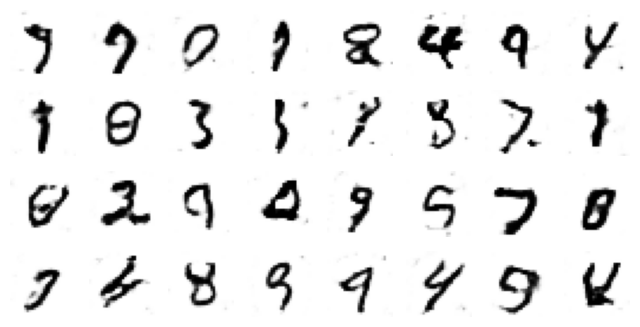


Generadas con vector de entrada tamaño 50:


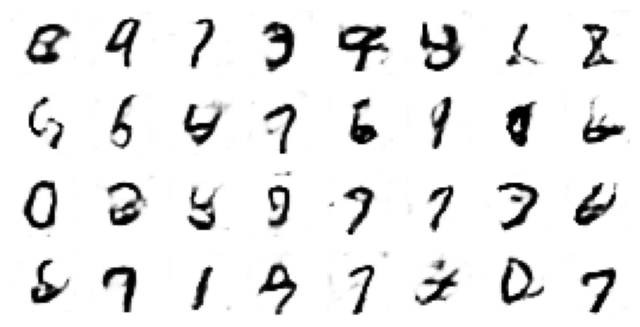


Generadas con vector de entrada tamaño 100:


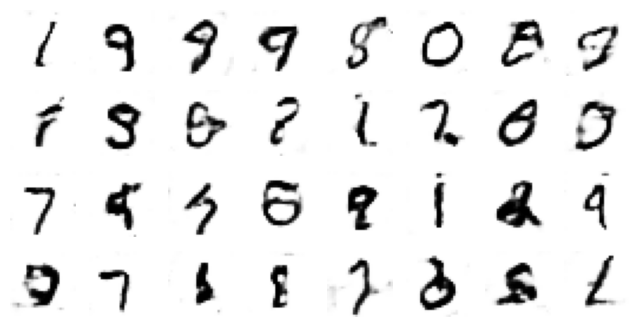

In [34]:
def plot_multiple_images(images, n_cols=None):
    # CORRECCIÓN: Convertimos el Tensor a Numpy array inmediatamente
    images = np.array(images)

    n_cols = n_cols or len(images)
    n_rows = (len(images) - 1) // n_cols + 1

    # Ahora que es un array de Numpy, .squeeze() funcionará perfectamente
    if images.shape[-1] == 1:
        images = images.squeeze(axis=-1)

    plt.figure(figsize=(n_cols, n_rows))
    for index, image in enumerate(images):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(image, cmap="binary")
        plt.axis("off")

# BUCLE DE VISUALIZACIÓN
for size in sizes_to_test:
    print(f"\nGeneradas con vector de entrada tamaño {size}:")

    # Generamos 32 imágenes
    noise = tf.random.normal(shape=[32, size])

    # Esto devuelve un Tensor
    generated_images = trained_generators[size](noise)

    # Mostramos el bloque (8 columnas x 4 filas)
    plot_multiple_images(generated_images, n_cols=8)
    plt.show()